# Tutorial 3 — Packet loss and failure counts

## 1. Problem / context

A link drops packets independently with probability $p=0.04$. In a burst of $n=50$ packets, how many losses should we expect, and what is $P(X\ge 5)$? Separately, rare hardware faults on a rack are modelled as a Poisson count with mean $\lambda=1.6$ faults per week.

Brooks Chapter 3 develops the PMF, CDF, and named discrete models. Here we connect those models to SciPy and to their assumptions.

## 2. Random variables, PMF, and CDF

A **random variable** $X$ assigns a number to each outcome of an experiment. Before we observe data we write $X$; after we see a number we write $x$.

For a discrete variable the **PMF** is $p_X(k)=P(X=k)$. The **CDF** is $F_X(k)=P(X\le k)$.

**Bernoulli**($p$): one trial, success probability $p$.

**Binomial**($n,p$): $n$ independent Bernoulli trials with the same $p$. The binomial coefficient $\binom{n}{k}$ counts the ways to place $k$ successes among $n$ trials:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}.
$$

The assumptions are a **fixed** $n$, a **constant** $p$, and **independence** across trials.

**Poisson**($\lambda$): a counting model for events in a window of time or space, with $E[X]=\operatorname{Var}(X)=\lambda$. It is a reasonable working model when the rate is stable over that window.

## 3. From mathematics to SciPy

| Need | Mathematics | SciPy |
| --- | --- | --- |
| $P(X=k)$ | $p_X(k)$ | `binom.pmf(k, n, p)` |
| $P(X\le k)$ | $F_X(k)$ | `binom.cdf(k, n, p)` |
| $P(X>k)$ | $1-F_X(k)$ | `binom.sf(k, n, p)` |
| $P(X\ge k)$ | $P(X>k-1)$ | `binom.sf(k-1, n, p)` |
| Quantile | smallest $k$ with $F_X(k)\ge q$ | `binom.ppf(q, n, p)` |

SciPy's survival function is $P(X>k)$, not $P(X\ge k)$. For an integer-valued variable,

$$
P(X\ge k)=P(X>k-1)=\texttt{dist.sf(k-1)}.
$$

Prefer `sf` over `1 - cdf(...)` in a far tail: subtracting two numbers that are both close to 1 can lose accuracy. The same table applies to `poisson` with `mu=lam`.

## 4. Packet losses: a binomial model


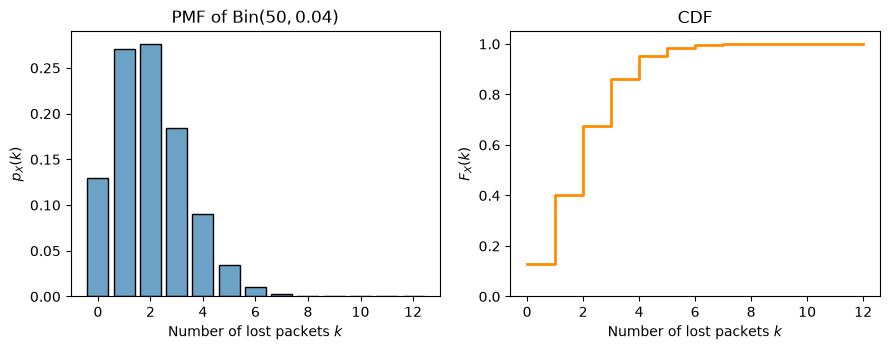

E[X] = 2.0  Var(X) = 1.92
P(X >= 5) = 0.04897147188451279
Smallest k with F(k) >= 0.90: 4


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import binom, poisson

n, p = 50, 0.04
k = np.arange(0, 13)
pmf = binom.pmf(k, n, p)
cdf = binom.cdf(k, n, p)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].bar(k, pmf, color="#6CA2C6", edgecolor="black")
axes[0].set_xlabel("Number of lost packets $k$")
axes[0].set_ylabel(r"$p_X(k)$")
axes[0].set_title(r"PMF of $\mathrm{Bin}(50, 0.04)$")

axes[1].step(k, cdf, where="post", color="#FF8C00", linewidth=2)
axes[1].set_xlabel("Number of lost packets $k$")
axes[1].set_ylabel(r"$F_X(k)$")
axes[1].set_title("CDF")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("E[X] =", binom.mean(n, p), " Var(X) =", binom.var(n, p))
print("P(X >= 5) =", binom.sf(4, n, p))
print("Smallest k with F(k) >= 0.90:", int(binom.ppf(0.90, n, p)))


`binom.sf(4, n, p)` is $P(X>4)=P(X\ge 5)$. The percent-point function answers a different question: the smallest loss count $k$ such that at least 90% of bursts have $X\le k$.

Empirical loss rate from the course file:


In [2]:
candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
loss = pd.read_csv(DATA / "packet_loss.csv")
p_hat = loss["packet_lost"].mean()
print("Observed loss rate:", p_hat)
print("In 50 trials, estimated mean losses:", 50 * p_hat)


Observed loss rate: 0.04
In 50 trials, estimated mean losses: 2.0


Treat $\hat p$ as an **estimate** of a packet-loss probability, not as proof that losses are independent Bernoulli trials with constant $p$. The binomial probabilities above use the stated model $p=0.04$; the CSV is a separate check of the order of magnitude.

Pause: if consecutive packet losses tended to cluster (a bursty link), which binomial assumption would be the first to fail?

## 5. Weekly faults: a Poisson model


In [3]:
lam = 1.6
print("P(no fault in a week) =", poisson.pmf(0, mu=lam))
print("P(at least 3 faults) =", poisson.sf(2, mu=lam))


P(no fault in a week) = 0.20189651799465538
P(at least 3 faults) = 0.216641510180737


`poisson.sf(2, mu=lam)` is $P(X>2)=P(X\ge 3)$. The Poisson story is a **rate in a window**, not a fixed number of Bernoulli trials. It is plausible when faults occur independently at a stable weekly rate; it is not a substitute for $\operatorname{Bin}(50, 0.04)$.

## 6. Interpretation and assumptions

If losses are independent with $p=0.04$, five or more losses in 50 packets is a right-tail event, not a typical burst. Revisit the assumptions before using that probability in a report:

- binomial: fixed $n$, constant $p$, independent packets;
- Poisson: a stable rate and a window in which counting faults makes sense.

## 7. Common mistakes / things to notice

- Using Poisson for a fixed number of packet trials (use binomial).
- Computing $P(X\ge k)$ as `sf(k)` instead of `sf(k-1)`.
- Preferring `1 - cdf(...)` in a far tail.
- Treating an empirical loss rate as confirmation of independence.
- Writing $X\sim N(\mu,\sigma)$ later in the course — wait for Session 04, and then use variance $\sigma^2$.

## 8. Short worked example

A plant inspects 20 boards. Each is independently non-conforming with probability 0.03. Find $P(X=0)$ and $P(X\ge 2)$.


In [4]:
print(binom.pmf(0, 20, 0.03))
print(binom.sf(1, 20, 0.03))


0.5437943429267472
0.11983802227320284


**Conclusion:** Packet losses in a fixed burst are a binomial count. With $n=50$ and $p=0.04$, $P(X\ge 5)=\texttt{binom.sf(4, 50, 0.04)}$, which is small but not negligible for reliability reporting. The Poisson rack-fault model answers a different question, with a rate rather than a fixed number of trials.
